In [2]:
import os
import json
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision import models

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

from tqdm import tqdm

In [3]:
def set_seed(seed= 42):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device: {device}")

if torch.cuda.is_available():

    print(torch.cuda.get_device_name(0))

using device: cuda
NVIDIA GeForce RTX 2060


In [4]:
LABELS_PATH="labels.json"
with open(LABELS_PATH, "r") as f:
    data=json.load(f)
ingredient_mapping=data["ingredient_mapping"]
mixed_labels=data["labels"]

NUM_CLASSES=len(ingredient_mapping)

print("Количество ингредиентов:", NUM_CLASSES)

Количество ингредиентов: 16


In [5]:
transform=transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
class IngredientDataset(Dataset):
    def __init__(
        self,
        image_paths,
        labels,
        transform=None
    ):
        self.image_paths=image_paths
        self.labels=labels
        self.transform=transform
    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path=self.image_paths[idx]
        image=Image.open(img_path).convert("RGB")
        if self.transform:
            image=self.transform(image)
        label_vector=torch.FloatTensor(
            self.labels[idx]
        )

        return image, label_vector

In [7]:
def create_multi_hot(label_ids, num_classes):
    vector=np.zeros(num_classes)
    for label in label_ids:
        vector[label-1]=1

    return vector

In [8]:
DATA_DIR="data"
single_image_paths=[]
single_labels=[]

for ingredient_id, ingredient_name in ingredient_mapping.items():
    ingredient_folder=os.path.join(DATA_DIR, ingredient_name)
    if not os.path.exists(ingredient_folder):
        continue
    images=os.listdir(ingredient_folder)
    for image_name in images:
        image_path= os.path.join(ingredient_folder, image_name)
        single_image_paths.append(image_path)
        vector=create_multi_hot(
            [int(ingredient_id)],
            NUM_CLASSES
        )

        single_labels.append(vector)

print("Single images:", len(single_image_paths))

Single images: 1101


In [9]:
mixed_folder=os.path.join(DATA_DIR, "mixed")
mixed_image_paths=[]
mixed_vectors=[]

for image_name, labels_list in mixed_labels.items():
    image_path=os.path.join(mixed_folder, image_name)
    if not os.path.exists(image_path):
        continue
    mixed_image_paths.append(image_path)
    vector =create_multi_hot(
        labels_list,
        NUM_CLASSES
    )
    mixed_vectors.append(vector)

print("Mixed images:", len(mixed_image_paths))

Mixed images: 274


In [10]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(mixed_image_paths, mixed_vectors, test_size=0.3, random_state=42, shuffle=True)
val_paths, test_paths, val_labels, test_labels = train_test_split(temp_paths, temp_labels, test_size=0.5, random_state=42, shuffle=True)
print("train:", len(train_paths))
print("validation:", len(val_paths))
print("test:", len(test_paths))

train: 191
validation: 41
test: 42


In [11]:
train_dataset = IngredientDataset(image_paths=train_paths, labels=train_labels, transform=transform)
val_dataset = IngredientDataset(image_paths=val_paths, labels=val_labels, transform=transform)
test_dataset = IngredientDataset(image_paths=test_paths,labels=test_labels, transform=transform)

print("Datasets created")

Datasets created


In [12]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader=DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader=DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Dataloaders created")

Dataloaders created


In [13]:
model=models.resnet18(weights="DEFAULT")
in_features = model.fc.in_features

model.fc=nn.Linear(
    in_features,
    NUM_CLASSES
)
model=model.to(device)
print("Model loaded")

Model loaded


In [14]:
import torch.optim as optim
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [15]:
def train_one_epoch(model, loader):

    model.train()
    total_loss=0
    for images, labels in loader:
        images=images.to(device)
        labels=labels.to(device)
        optimizer.zero_grad()
        outputs =model(images)
        loss=criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss+=loss.item()

    avg_loss=total_loss/len(loader)
    return avg_loss

In [16]:
def validate(model, loader):
    model.eval()
    total_loss=0
    with torch.no_grad():
        for images, labels in loader:
            images=images.to(device)
            labels=labels.to(device)
            outputs=model(images)
            loss=criterion(outputs, labels)
            total_loss+=loss.item()

    avg_loss=total_loss/len(loader)
    return avg_loss

In [17]:
num_epochs=10
train_losses=[]
val_losses=[]
for epoch in range(num_epochs):
    train_loss= train_one_epoch(model, train_loader)

    val_loss=validate(model, val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")


Epoch 1/10
Train Loss: 0.4833
Val Loss: 0.6908

Epoch 2/10
Train Loss: 0.2893
Val Loss: 0.5314

Epoch 3/10
Train Loss: 0.2406
Val Loss: 0.7931

Epoch 4/10
Train Loss: 0.1763
Val Loss: 0.5760

Epoch 5/10
Train Loss: 0.1754
Val Loss: 0.4613

Epoch 6/10
Train Loss: 0.1404
Val Loss: 0.5488

Epoch 7/10
Train Loss: 0.1359
Val Loss: 0.6482

Epoch 8/10
Train Loss: 0.1150
Val Loss: 0.3788

Epoch 9/10
Train Loss: 0.1284
Val Loss: 0.3992

Epoch 10/10
Train Loss: 0.0988
Val Loss: 0.4545


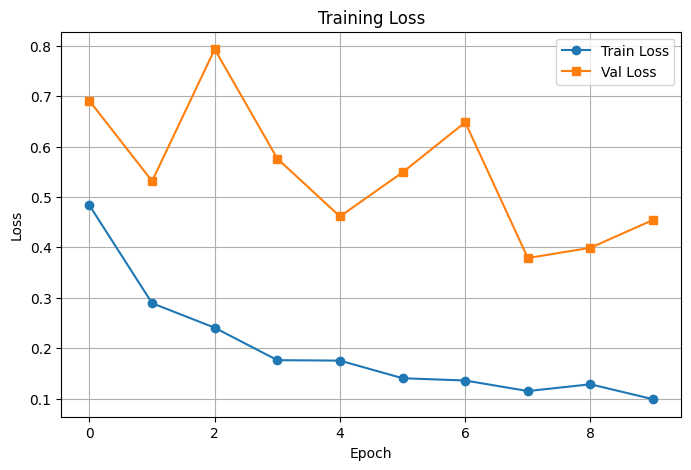

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss", marker="o")
plt.plot(val_losses, label="Val Loss", marker="s")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training Loss")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
def predict_image(model, image_path, threshold=0.5):
    model.eval()
    image=Image.open(image_path).convert("RGB")
    image_tensor=transform(image)
    image_tensor=image_tensor.unsqueeze(0)
    image_tensor=image_tensor.to(device)
    with torch.no_grad():
        outputs=model(image_tensor)
        probs=torch.sigmoid(outputs)[0]
    predicted_ingredients=[]
    for i, prob in enumerate(probs):
        if prob >=threshold:
            ingredient_name=ingredient_mapping[str(i + 1)]
            predicted_ingredients.append((ingredient_name,float(prob)))

    predicted_ingredients.sort(
        key=lambda x: x[1],
        reverse=True
    )

    return predicted_ingredients

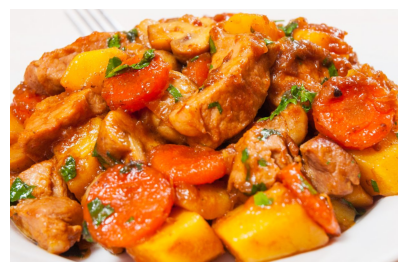

Predictions:

tomato: 0.817
sausage_boiled: 0.742
bread: 0.542




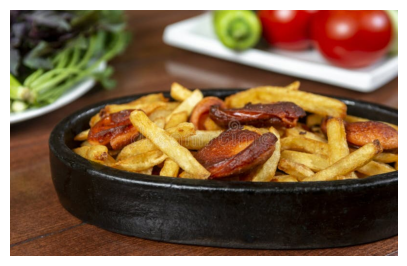

Predictions:

sausage_boiled: 0.930
cucumber: 0.644
potato: 0.514




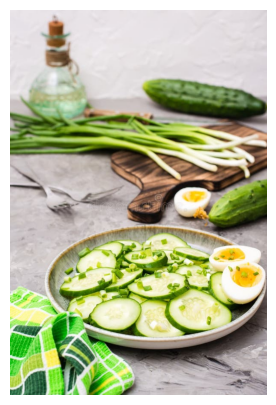

Predictions:

cucumber: 0.980
egg_boiled: 0.911
lettuce: 0.885
tomato: 0.631




In [23]:
random_images=random.sample(test_paths, 3)
for image_path in random_images:

    predictions=predict_image(model, image_path, threshold=0.5)
    image=Image.open(image_path)

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
    print("Predictions:\n")

    for ingredient, prob in predictions:
        print(f"{ingredient}: {prob:.3f}")
    print("\n" + "="*50 + "\n")

In [21]:
torch.save(model.state_dict(), "ingredient_model_mixed.pth")

print("saved")

saved


In [24]:
single_dataset = IngredientDataset(image_paths=single_image_paths, labels=single_labels, transform=transform)
print("single dataset size:", len(single_dataset))
single_train_paths, single_val_paths, single_train_labels, single_val_labels = train_test_split(single_image_paths, single_labels, test_size=0.2,random_state=42, shuffle=True)

print("single train:", len(single_train_paths))
print("single val:", len(single_val_paths))

single dataset size: 1101
single train: 880
single val: 221


In [26]:
single_train_dataset = IngredientDataset(image_paths=single_train_paths, labels=single_train_labels, transform=transform)
single_val_dataset = IngredientDataset(image_paths=single_val_paths, labels=single_val_labels, transform=transform)

single_train_loader = DataLoader(single_train_dataset, batch_size=16, shuffle=True)
single_val_loader = DataLoader(single_val_dataset, batch_size=16, shuffle=False)

In [27]:
model_B=models.resnet18(weights="DEFAULT")
in_features=model_B.fc.in_features
model_B.fc= nn.Linear(in_features, NUM_CLASSES)
model_B=model_B.to(device)

criterion_B=nn.BCEWithLogitsLoss()

optimizer_B=optim.Adam(model_B.parameters(), lr=0.001)

In [29]:
def train_one_epoch_B(model, loader):
    model.train()
    total_loss=0
    for images, labels in loader:
        images=images.to(device)
        labels=labels.to(device)
        optimizer_B.zero_grad()
        outputs=model(images)
        loss=criterion_B(outputs, labels)
        loss.backward()
        optimizer_B.step()
        total_loss+=loss.item()
    avg_loss=total_loss/len(loader)

    return avg_loss

def validate_B(model, loader):
    model.eval()
    total_loss=0
    with torch.no_grad():
        for images, labels in loader:
            images=images.to(device)
            labels=labels.to(device)
            outputs=model(images)
            loss=criterion_B(outputs, labels)
            total_loss+=loss.item()
    avg_loss =total_loss/len(loader)

    return avg_loss

In [30]:
num_epochs_stage1=5
single_train_losses=[]
single_val_losses=[]
for epoch in range(num_epochs_stage1):
    train_loss=train_one_epoch_B(model_B, single_train_loader)
    val_loss=validate_B(model_B, single_val_loader)
    single_train_losses.append(train_loss)
    single_val_losses.append(val_loss)

    print(f"\nStage 1(only single) Epoch {epoch+1}/{num_epochs_stage1}")

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")

c:\Users\Professional\.conda\envs\kursach_env\lib\site-packages\PIL\Image.py:975: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Stage 1(only single) Epoch 1/5
Train Loss: 0.1900
Val Loss:   0.1738

Stage 1(only single) Epoch 2/5
Train Loss: 0.1191
Val Loss:   0.1848

Stage 1(only single) Epoch 3/5
Train Loss: 0.1034
Val Loss:   0.1175

Stage 1(only single) Epoch 4/5
Train Loss: 0.0894
Val Loss:   0.1301

Stage 1(only single) Epoch 5/5
Train Loss: 0.0860
Val Loss:   0.1117


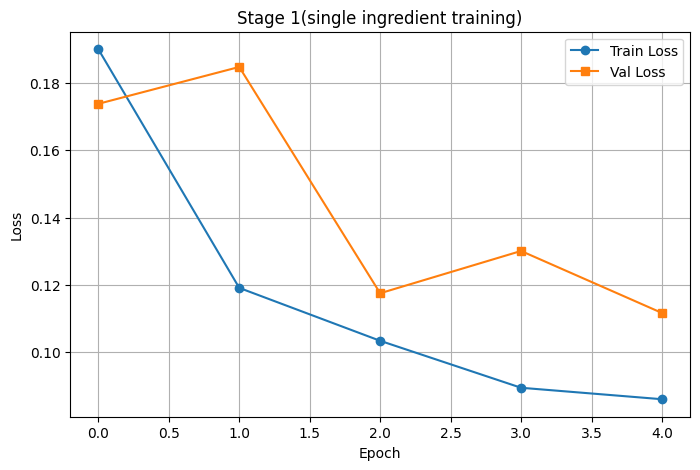

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(single_train_losses, label="Train Loss", marker="o")
plt.plot(single_val_losses, label="Val Loss", marker="s")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Stage 1(single ingredient training)")
plt.legend()
plt.grid(True)

plt.show()

In [32]:
num_epochs_stage2=7
mixed_train_losses=[]
mixed_val_losses=[]
for epoch in range(num_epochs_stage2):
    train_loss=train_one_epoch_B(model_B, train_loader)
    val_loss=validate_B(model_B, val_loader)
    mixed_train_losses.append(train_loss)
    mixed_val_losses.append(val_loss)

    print(f"\nStage 2(added mixed) Epoch {epoch+1}/{num_epochs_stage2}")

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")


Stage 2(added mixed) Epoch 1/7
Train Loss: 0.6230
Val Loss:   1.8681

Stage 2(added mixed) Epoch 2/7
Train Loss: 0.3590
Val Loss:   0.5350

Stage 2(added mixed) Epoch 3/7
Train Loss: 0.3008
Val Loss:   0.4437

Stage 2(added mixed) Epoch 4/7
Train Loss: 0.2604
Val Loss:   0.4677

Stage 2(added mixed) Epoch 5/7
Train Loss: 0.2143
Val Loss:   0.3922

Stage 2(added mixed) Epoch 6/7
Train Loss: 0.1970
Val Loss:   0.4151

Stage 2(added mixed) Epoch 7/7
Train Loss: 0.1480
Val Loss:   0.3452


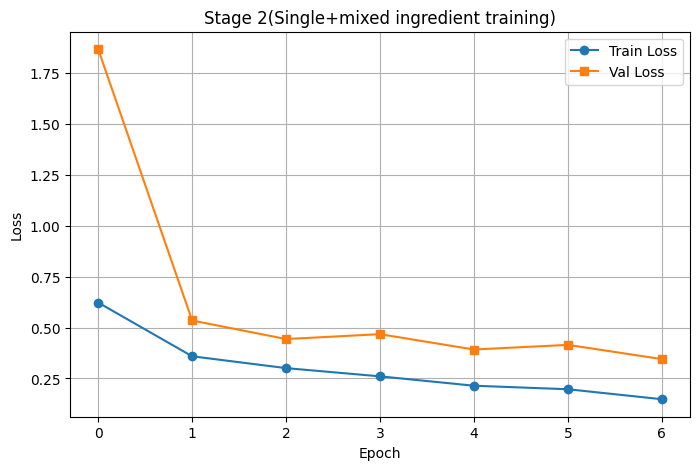

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(mixed_train_losses, label="Train Loss", marker="o")
plt.plot(mixed_val_losses, label="Val Loss", marker="s")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Stage 2(Single+mixed ingredient training)")
plt.legend()
plt.grid(True)

plt.show()

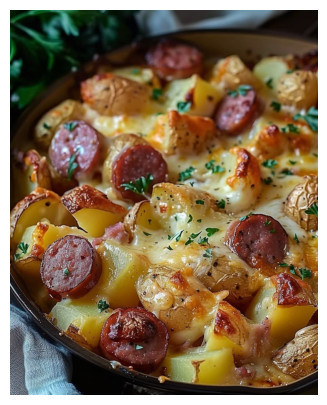

Predictions:

sausage_boiled: 0.689




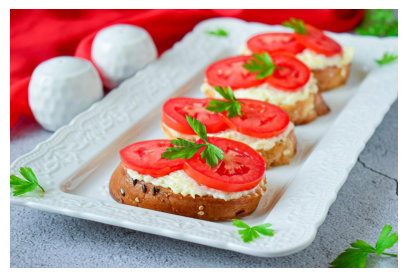

Predictions:

tomato: 0.987
bread: 0.872




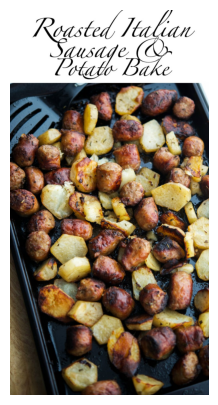

Predictions:

sausage_boiled: 0.861
potato: 0.581




In [42]:
random_images=random.sample(test_paths, 3)

for image_path in random_images:
    predictions=predict_image(model_B, image_path, threshold=0.5)
    image=Image.open(image_path)

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    print("Predictions:\n")

    for ingredient, prob in predictions:
        print(f"{ingredient}: {prob:.3f}")

    print("\n" + "="*50 + "\n")

In [43]:
torch.save(model_B.state_dict(), "ingredient_model_B.pth")
print("model_B saved")

model_B saved


In [44]:
combined_image_paths = (single_image_paths+mixed_image_paths)
combined_labels=(single_labels+mixed_vectors)
print("Combined images:", len(combined_image_paths))
train_paths_C, temp_paths_C, train_labels_C, temp_labels_C = train_test_split(combined_image_paths, combined_labels, test_size=0.3, random_state=42, shuffle=True)
val_paths_C, test_paths_C, val_labels_C, test_labels_C = train_test_split(temp_paths_C, temp_labels_C, test_size=0.5, random_state=42, shuffle=True)

print("Train:", len(train_paths_C))
print("Validation:", len(val_paths_C))
print("Test:", len(test_paths_C))

Combined images: 1375
Train: 962
Validation: 206
Test: 207


In [45]:
train_dataset_C=IngredientDataset(image_paths=train_paths_C, labels=train_labels_C, transform=transform)
val_dataset_C=IngredientDataset(image_paths=val_paths_C, labels=val_labels_C, transform=transform)
test_dataset_C=IngredientDataset(image_paths=test_paths_C, labels=test_labels_C, transform=transform)

train_loader_C=DataLoader(train_dataset_C, batch_size=16, shuffle=True)
val_loader_C=DataLoader(val_dataset_C, batch_size=16, shuffle=False)
test_loader_C=DataLoader(test_dataset_C, batch_size=16, shuffle=False)

In [47]:
model_C=models.resnet18(weights="DEFAULT")
in_features=model_C.fc.in_features

model_C.fc=nn.Linear(in_features, NUM_CLASSES)
model_C=model_C.to(device)

criterion_C=nn.BCEWithLogitsLoss()
optimizer_C=optim.Adam(model_C.parameters(), lr=0.001)

print("Model C loaded")

Model C loaded


In [48]:
def train_one_epoch_C(model, loader):
    model.train()
    total_loss=0
    for images, labels in loader:
        images=images.to(device)
        labels=labels.to(device)
        optimizer_C.zero_grad()
        outputs=model(images)
        loss=criterion_C(outputs, labels)
        loss.backward()
        optimizer_C.step()
        total_loss+=loss.item()
    avg_loss=total_loss/len(loader)

    return avg_loss

def validate_C(model, loader):
    model.eval()
    total_loss=0
    with torch.no_grad():
        for images, labels in loader:
            images=images.to(device)
            labels=labels.to(device)
            outputs=model(images)
            loss=criterion_C(outputs, labels)
            total_loss+=loss.item()
    avg_loss=total_loss/len(loader)

    return avg_loss

In [49]:
num_epochs_C=10
train_losses_C=[]
val_losses_C=[]
for epoch in range(num_epochs_C):
    train_loss=train_one_epoch_C(model_C, train_loader_C)
    val_loss=validate_C(model_C, val_loader_C)
    train_losses_C.append(train_loss)
    val_losses_C.append(val_loss)

    print(f"\nmodel_C Epoch {epoch+1}/{num_epochs_C}")

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")

c:\Users\Professional\.conda\envs\kursach_env\lib\site-packages\PIL\Image.py:975: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



model_C Epoch 1/10
Train Loss: 0.2721
Val Loss:   0.4897

model_C Epoch 2/10
Train Loss: 0.2070
Val Loss:   0.2617

model_C Epoch 3/10
Train Loss: 0.1888
Val Loss:   0.1983

model_C Epoch 4/10
Train Loss: 0.1635
Val Loss:   0.1908

model_C Epoch 5/10
Train Loss: 0.1461
Val Loss:   0.2242

model_C Epoch 6/10
Train Loss: 0.1358
Val Loss:   0.2206

model_C Epoch 7/10
Train Loss: 0.1378
Val Loss:   0.1806

model_C Epoch 8/10
Train Loss: 0.1114
Val Loss:   0.2271

model_C Epoch 9/10
Train Loss: 0.1161
Val Loss:   0.1725

model_C Epoch 10/10
Train Loss: 0.1014
Val Loss:   0.2447


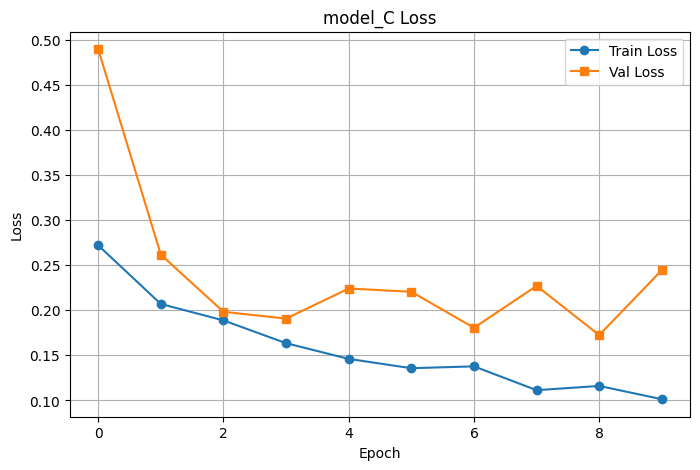

In [50]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_C, label="Train Loss", marker="o")
plt.plot(val_losses_C, label="Val Loss", marker="s")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("model_C Loss")
plt.legend()
plt.grid(True)

plt.show()

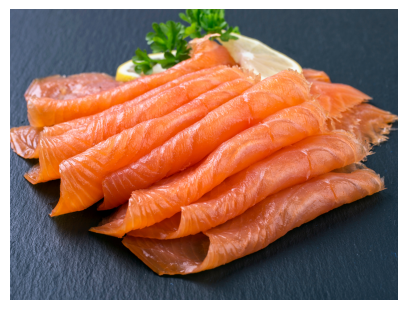

predictions:

smoked_salmon_slices: 0.975




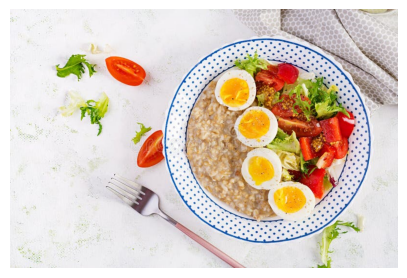

predictions:

egg_boiled: 0.993
oatmeal_porridge: 0.978
tomato: 0.886
lettuce: 0.526




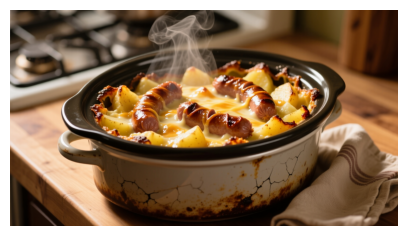

predictions:

pasta: 0.999




In [55]:
random_images=random.sample(test_paths_C, 3)
for image_path in random_images:
    predictions=predict_image(model_C, image_path, threshold=0.5)
    image=Image.open(image_path)

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    print("predictions:\n")

    for ingredient, prob in predictions:
        print(f"{ingredient}: {prob:.3f}")

    print("\n" + "="*50 + "\n")

In [56]:
torch.save(model_C.state_dict(), "ingredient_model_C.pth")

print("model_C saved")

model_C saved
